In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

In [72]:
def get_number_pocket_triplets(df):
    return len(set(tuple(sorted([i, j, k])) for i, j, k in zip(df['pocket1'], df['pocket2'], df['pocket3'])))

def get_number_protein_triplets(df):
    return len(set(tuple(sorted([i, j, k])) for i, j, k in zip(df['protein1'], df['protein2'], df['protein3'])))

In [3]:
#####################################################
#####################################################
###############------ PHASE 1 ------#################
#####################################################
#####################################################

In [4]:
###########  TRIPLETS  ###########

In [5]:
ALL_RESULTS_TRIPLETS = pd.read_csv("../processed/protein_prioritization/triplets.tsv", sep='\t', low_memory=False)
ALL_RESULTS_TRIPLETS["interpro_pocket1"] = ALL_RESULTS_TRIPLETS["interpro_pocket1"].fillna("").astype(str)
ALL_RESULTS_TRIPLETS["interpro_pocket2"] = ALL_RESULTS_TRIPLETS["interpro_pocket2"].fillna("").astype(str)
ALL_RESULTS_TRIPLETS["interpro_pocket3"] = ALL_RESULTS_TRIPLETS["interpro_pocket3"].fillna("").astype(str)

proteins = sorted(set(ALL_RESULTS_TRIPLETS['protein1']).union(set(ALL_RESULTS_TRIPLETS['protein2'])).union(set(ALL_RESULTS_TRIPLETS['protein3'])))

In [6]:
RMSD_CUT_OFF = 10
SEQID_CUT_OFF = 30

In [7]:
# CATALYTIC COUNTS
CATALYTIC_COUNTS = []
for i,j,k in zip(ALL_RESULTS_TRIPLETS['interpro_pocket1'], ALL_RESULTS_TRIPLETS['interpro_pocket2'], ALL_RESULTS_TRIPLETS['interpro_pocket3']):
    counts = []
    for interpro in [i,k,j]:
        if "Catalytic Domain (ATP Binding Site)" in interpro:
            counts.append(1)
        else:
            counts.append(0)
    CATALYTIC_COUNTS.append(sum(counts))
ALL_RESULTS_TRIPLETS['catalytic_counts'] = CATALYTIC_COUNTS


# GLOBAL SIMILARITY
GLOBAL_SIMILARITY = []
for seqidA, seqidB, seqidC, rmsdA, rmsdB, rmsdC in zip(ALL_RESULTS_TRIPLETS['SEQ_ID_CO_A'], ALL_RESULTS_TRIPLETS['SEQ_ID_CO_B'], ALL_RESULTS_TRIPLETS['SEQ_ID_CO_C'], 
                                                    ALL_RESULTS_TRIPLETS['RMSD_A'], ALL_RESULTS_TRIPLETS['RMSD_B'], ALL_RESULTS_TRIPLETS['RMSD_C']):
    counts = []
    if seqidA > SEQID_CUT_OFF or rmsdA < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    if seqidB > SEQID_CUT_OFF or rmsdB < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    if seqidC > SEQID_CUT_OFF or rmsdC < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    GLOBAL_SIMILARITY.append(sum(counts))
ALL_RESULTS_TRIPLETS['global_similarity'] = GLOBAL_SIMILARITY

In [8]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_ALL = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 7,743[47]
GS 0 -- CAT 1 -- 133,549[311]
GS 0 -- CAT 2 -- 395,657[422]
GS 1 -- CAT 0 -- 28,795[106]
GS 1 -- CAT 1 -- 238,208[502]
GS 1 -- CAT 2 -- 821,686[723]
GS 2 -- CAT 0 -- 68,166[142]
GS 2 -- CAT 1 -- 315,821[447]
GS 2 -- CAT 2 -- 489,633[521]


In [9]:
sum(TOTAL)

2499258

In [10]:
ALL_RESULTS_TRIPLETS_POCKETVEC_017 = ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['dist_A'] < 0.17) & 
                                                          (ALL_RESULTS_TRIPLETS['dist_B'] < 0.17) & 
                                                          (ALL_RESULTS_TRIPLETS['dist_C'] < 0.17)].reset_index(drop=True)

In [11]:
len(ALL_RESULTS_TRIPLETS_POCKETVEC_017)

3880

In [12]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_017 = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 1[1]
GS 0 -- CAT 1 -- 69[30]
GS 0 -- CAT 2 -- 498[75]
GS 1 -- CAT 0 -- 9[6]
GS 1 -- CAT 1 -- 67[41]
GS 1 -- CAT 2 -- 2,191[163]
GS 2 -- CAT 0 -- 17[11]
GS 2 -- CAT 1 -- 165[61]
GS 2 -- CAT 2 -- 863[117]


In [13]:
sum(TOTAL)

3880

In [14]:
ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE = ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['dist_A'] < 0.17) & 
                                                               (ALL_RESULTS_TRIPLETS['dist_B'] < 0.17) & 
                                                               (ALL_RESULTS_TRIPLETS['dist_C'] < 0.17)].reset_index(drop=True)

ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_A'] < 0.13) |
                                                                                   (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_B'] < 0.13) |
                                                                                   (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_C'] < 0.13)].reset_index(drop=True)

In [15]:
len(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE)

375

In [16]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 0[0]
GS 0 -- CAT 1 -- 2[2]
GS 0 -- CAT 2 -- 55[16]
GS 1 -- CAT 0 -- 0[0]
GS 1 -- CAT 1 -- 5[4]
GS 1 -- CAT 2 -- 184[52]
GS 2 -- CAT 0 -- 0[0]
GS 2 -- CAT 1 -- 8[7]
GS 2 -- CAT 2 -- 121[36]


In [17]:
sum(TOTAL)

375

In [18]:
#####################################################
#####################################################
###############------ PHASE 2 ------#################
#####################################################
#####################################################

In [19]:
#####################################################
#####################################################
###############------ PHASE 3 ------#################
#####################################################
#####################################################

In [20]:
###########  TRIPLETS  ###########

In [31]:
ERSILIA_COLORS = {(0,0): '#50285A', 
                  (0,1): '#FAD782', 
                  (0,2): '#FAA08B', 
                  (1,0): '#DC9FDC', 
                  (1,1): '#AA96FA', 
                  (1,2): '#8DC7FA', 
                  (2,0): '#BEE6B4', 
                  (2,1): '#D2D2D2', 
                  (2,2): 'w'}

inds = sorted(ERSILIA_COLORS)

In [32]:
### ALL RESULTS ###

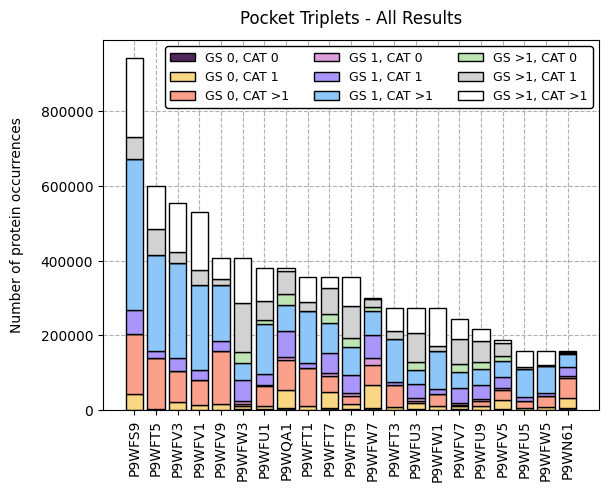

In [36]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_ALL, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_ALL[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_ALL[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All Results", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [37]:
### POCKETVEC < 0.17 ###

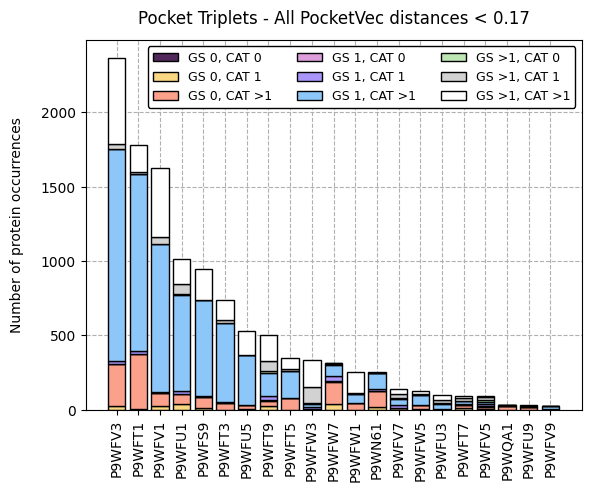

In [34]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_017, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_017[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [ ]:
### POCKETVEC < 0.17 & MORE ###

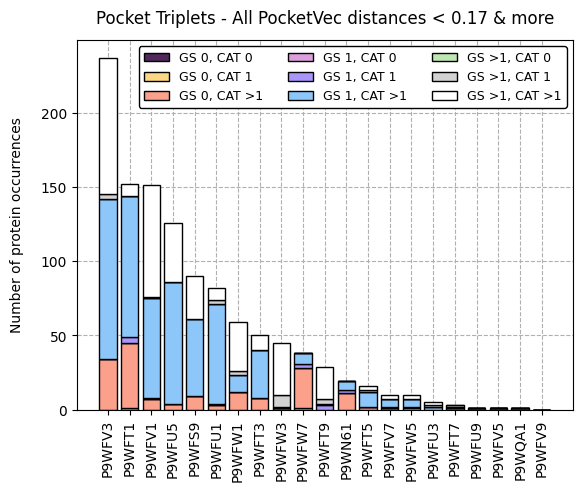

In [38]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All PocketVec distances < 0.17 & more", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [39]:
### NOW FROM THE DOMAIN PERSPECTIVE ... ###

In [56]:
ERSILIA_COLORS = ['#50285A', '#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4', '#D2D2D2'][1:]

In [65]:
### ALL RESULTS ###

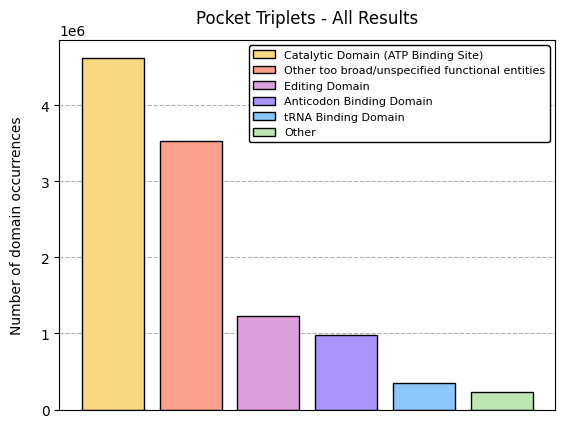

In [64]:
interpro_domains = ALL_RESULTS_TRIPLETS['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All Results", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [66]:
### POCKETVEC < 0.17 ###

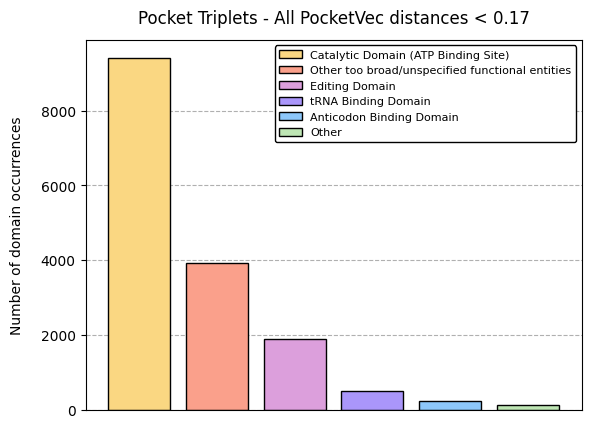

In [68]:
interpro_domains = ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [67]:
### POCKETVEC < 0.17 & MORE ###

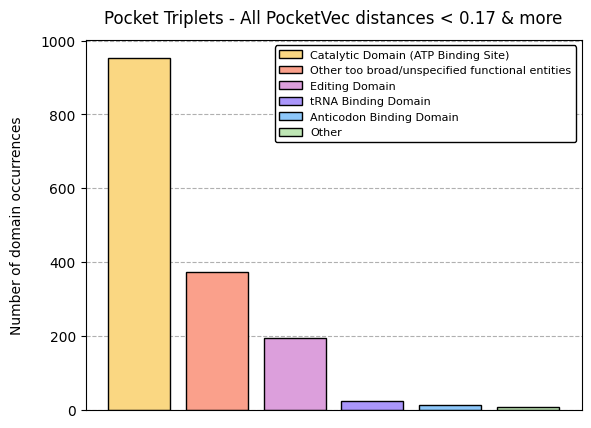

In [71]:
interpro_domains = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All PocketVec distances < 0.17 & more", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()